# Minería de datos — Unidad I
## Representación de datos, análisis exploratorio, PCA y agrupamiento

**Semestre:** 2027-1  
**Profesor:** Dr. Ulises Olivares Pinto  


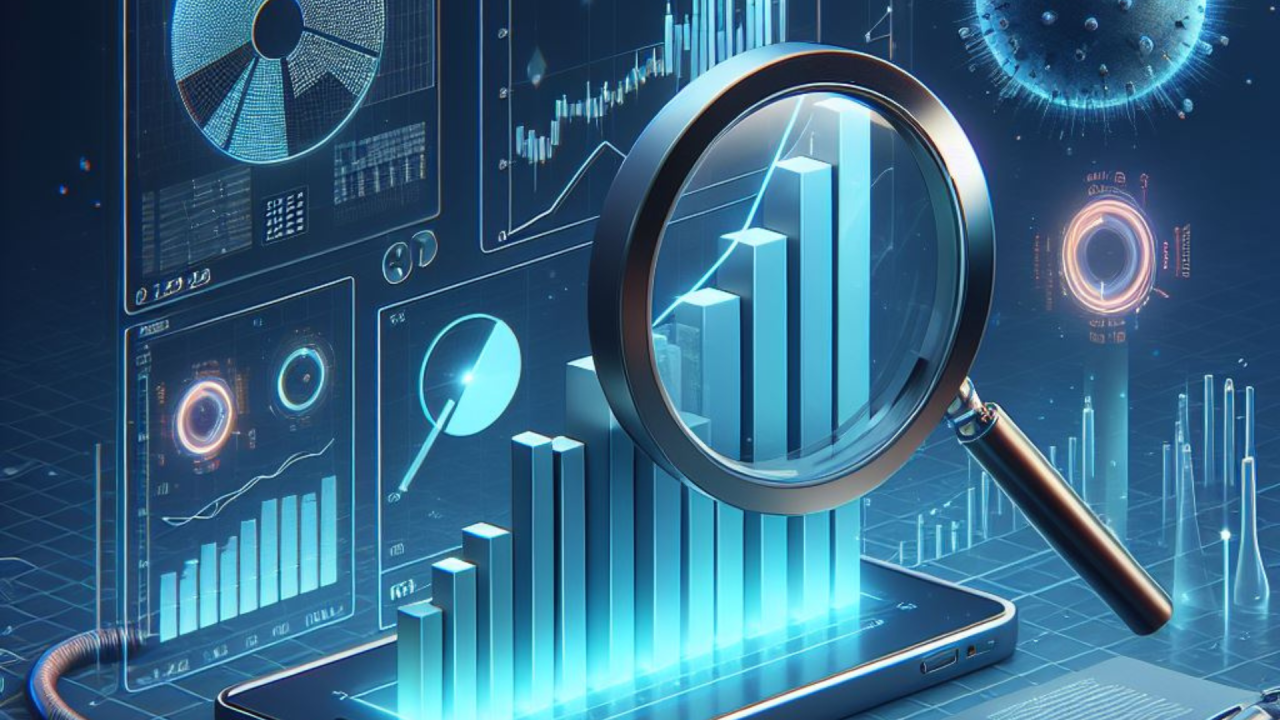

## Resultados de aprendizaje

Al finalizar el notebook podrás:

1. distinguir instancias, atributos y variable objetivo;
2. reconocer tipos y escalas de medición;
3. realizar un análisis exploratorio reproducible;
4. evitar fugas de información al dividir y transformar datos;
5. aplicar PCA e interpretar la varianza explicada;
6. aplicar y evaluar agrupamiento con K-means.

Los ejemplos utilizan conjuntos de datos reales incluidos en `scikit-learn`, por lo que no requieren descargas externas.


## 0. Preparación del entorno

La semilla fija permite reproducir los resultados. Se centralizan aquí las importaciones para evitar celdas duplicadas.


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine, load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 12)


# 1. De un problema real a una tabla analítica

Usaremos el conjunto **Breast Cancer Wisconsin (Diagnostic)**. Cada fila representa una biopsia por aspiración con aguja fina; los atributos describen características calculadas a partir de imágenes digitalizadas de núcleos celulares. La variable objetivo indica si el tumor es maligno o benigno.

> Pregunta analítica: ¿qué patrones distinguen los tumores malignos de los benignos?


In [4]:
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()
df['diagnostico'] = df['target'].map({0: 'maligno', 1: 'benigno'})

print(f'Instancias: {df.shape[0]:,}')
print(f'Atributos predictivos: {cancer.data.shape[1]}')
print(df[['mean radius', 'mean texture', 'mean area', 'diagnostico']].head(10))


Instancias: 569
Atributos predictivos: 30
   mean radius  mean texture  mean area diagnostico
0        17.99         10.38     1001.0     maligno
1        20.57         17.77     1326.0     maligno
2        19.69         21.25     1203.0     maligno
3        11.42         20.38      386.1     maligno
4        20.29         14.34     1297.0     maligno
5        12.45         15.70      477.1     maligno
6        18.25         19.98     1040.0     maligno
7        13.71         20.83      577.9     maligno
8        13.00         21.82      519.8     maligno
9        12.46         24.04      475.9     maligno


## 1.1 Anatomía y tipos de atributos

- **Instancia:** una biopsia.
- **Atributos numéricos continuos:** radio, textura, perímetro y área.
- **Variable objetivo binaria:** diagnóstico.
- **Metadatos:** definición, unidad y procedencia de cada medición.

La escala condiciona las operaciones válidas. Por ejemplo, el área admite razones, mientras que una etiqueta nominal solo permite comparar igualdad o diferencia.


In [5]:
diccionario = pd.DataFrame({
    'variable': ['mean radius', 'mean texture', 'mean area', 'diagnostico'],
    'rol': ['atributo', 'atributo', 'atributo', 'objetivo'],
    'tipo': ['numérico continuo', 'numérico continuo', 'numérico continuo', 'categórico binario'],
    'escala': ['razón', 'razón', 'razón', 'nominal'],
})
diccionario


,variable,rol,tipo,escala
0,mean radius,atributo,numérico continuo,razón
1,mean texture,atributo,numérico continuo,razón
2,mean area,atributo,numérico continuo,razón
3,diagnostico,objetivo,categórico binario,nominal


## 1.2 Control inicial de calidad

Antes de graficar o modelar se revisan dimensiones, tipos, valores faltantes, duplicados y rangos. Esta verificación evita interpretar errores de captura como patrones reales.


In [6]:
calidad = pd.Series({
    'filas': len(df),
    'columnas': df.shape[1],
    'valores_faltantes': int(df.isna().sum().sum()),
    'filas_duplicadas': int(df.duplicated().sum()),
})
calidad


filas                569
columnas              32
valores_faltantes      0
filas_duplicadas       0
dtype: int64

In [7]:
df[cancer.feature_names].describe().T[['mean', 'std', 'min', '50%', 'max']].head(10)


,mean,std,min,50%,max
mean radius,14.127292,3.524049,6.98100,13.37000,28.11000
mean texture,19.289649,4.301036,9.71000,18.84000,39.28000
mean perimeter,91.969033,24.298981,43.79000,86.24000,188.50000
mean area,654.889104,351.914129,143.50000,551.10000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.09587,0.16340
mean compactness,0.104341,0.052813,0.01938,0.09263,0.34540
mean concavity,0.088799,0.079720,0.00000,0.06154,0.42680
mean concave points,0.048919,0.038803,0.00000,0.03350,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.17920,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.06154,0.09744


# 2. Análisis exploratorio de datos (AED)

El AED combina preguntas, resúmenes y visualizaciones. No consiste en producir muchas gráficas, sino en encontrar evidencia relevante para la decisión.


## 2.1 ¿La variable objetivo está balanceada?

Una distribución desigual puede hacer engañosa la exactitud. Primero cuantificamos la proporción de cada clase.


In [8]:
balance = df['diagnostico'].value_counts().rename_axis('diagnostico').to_frame('casos')
balance['porcentaje'] = (100 * balance['casos'] / balance['casos'].sum()).round(1)
balance


,casos,porcentaje
diagnostico,,
benigno,357,62.7
maligno,212,37.3


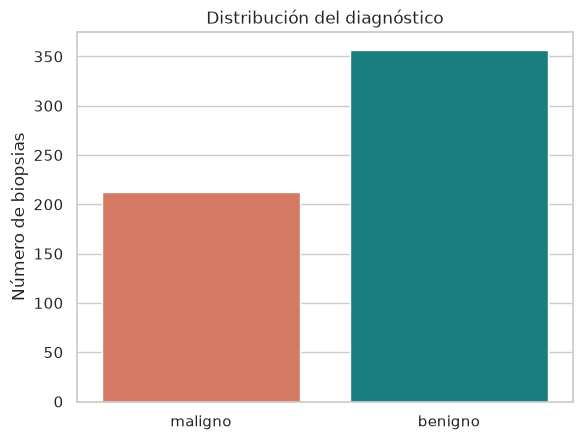

In [9]:
ax = sns.countplot(data=df, x='diagnostico', hue='diagnostico', legend=False,
                   palette=['#E76F51', '#0A8F8F'])
ax.set(title='Distribución del diagnóstico', xlabel='', ylabel='Número de biopsias')
plt.show()


## 2.2 ¿Qué variables separan mejor los diagnósticos?

Comparamos la distribución del radio medio. La superposición entre grupos recuerda que una sola variable rara vez resuelve por completo el problema.


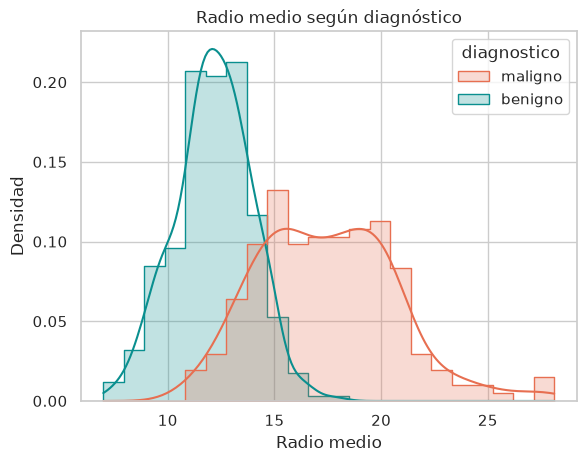

In [10]:
ax = sns.histplot(data=df, x='mean radius', hue='diagnostico', kde=True,
                  element='step', stat='density', common_norm=False,
                  palette=['#E76F51', '#0A8F8F'])
ax.set(title='Radio medio según diagnóstico', xlabel='Radio medio', ylabel='Densidad')
plt.show()


## 2.3 Relaciones y redundancia

Las variables geométricas pueden medir aspectos relacionados. Una correlación alta señala redundancia, no causalidad.


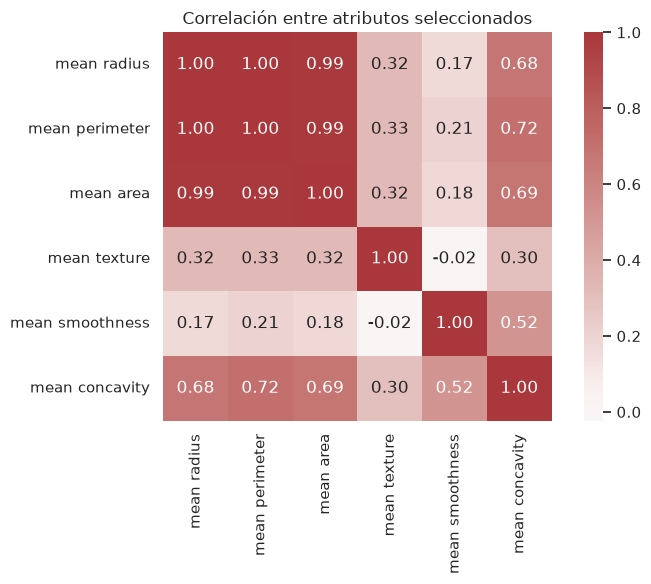

In [11]:
variables = ['mean radius', 'mean perimeter', 'mean area',
             'mean texture', 'mean smoothness', 'mean concavity']
corr = df[variables].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True)
plt.title('Correlación entre atributos seleccionados')
plt.tight_layout()
plt.show()


### Interpretación

- Radio, perímetro y área presentan una relación fuerte porque describen el tamaño del núcleo.
- La textura aporta información diferente y puede complementar las variables geométricas.
- PCA puede resumir parte de esta redundancia, pero no reemplaza la interpretación del dominio.


## 2.4 División correcta de datos

La partición se realiza **antes** de ajustar transformaciones. El escalador debe aprender media y desviación solo con entrenamiento; así evitamos fuga de información.


In [12]:
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)


Entrenamiento: (455, 30) | Prueba: (114, 30)


## Actividad 1 — Informe breve de AED

1. Selecciona tres atributos y justifica su relevancia.
2. Identifica un posible valor extremo y decide si es error o caso válido.
3. Explica una correlación alta sin afirmar causalidad.
4. Formula una conclusión que pueda apoyar una decisión clínica.

**Entregable:** una tabla, dos visualizaciones y tres conclusiones respaldadas por evidencia.


In [13]:
# Codificar aqui

# 3. Reducción de dimensionalidad con PCA

Usaremos el conjunto **Wine**, formado por 178 análisis químicos de vinos italianos de tres cultivares. El objetivo es resumir 13 variables correlacionadas en pocos componentes.


In [14]:
wine = load_wine(as_frame=True)
X_wine = wine.data
y_wine = wine.target

print('Dimensiones originales:', X_wine.shape)
X_wine.head()


Dimensiones originales: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,...,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,...,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,...,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,...,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,...,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,...,0.39,1.82,4.32,1.04,2.93,735.0


## 3.1 Estandarizar antes de PCA

PCA maximiza varianza. Si las variables tienen escalas distintas, las de mayor magnitud dominan los componentes. Por eso se estandarizan primero.


In [15]:
X_wine_scaled = StandardScaler().fit_transform(X_wine)
pca_wine = PCA().fit(X_wine_scaled)

varianza = pd.DataFrame({
    'componente': np.arange(1, len(pca_wine.explained_variance_ratio_) + 1),
    'varianza_individual': pca_wine.explained_variance_ratio_,
    'varianza_acumulada': np.cumsum(pca_wine.explained_variance_ratio_),
})
varianza.head(20)


,componente,varianza_individual,varianza_acumulada
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


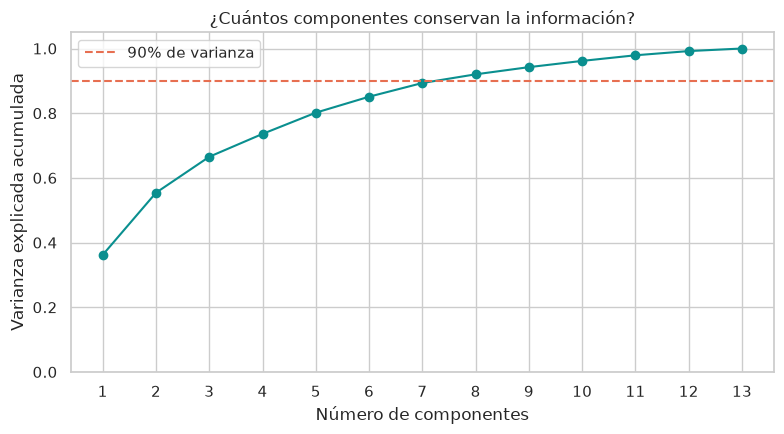

In [16]:
plt.figure(figsize=(8, 4.5))
plt.plot(varianza['componente'], varianza['varianza_acumulada'], marker='o', color='#0A8F8F')
plt.axhline(0.90, color='#E76F51', linestyle='--', label='90% de varianza')
plt.xticks(varianza['componente'])
plt.ylim(0, 1.05)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('¿Cuántos componentes conservan la información?')
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
n90 = int(np.argmax(varianza['varianza_acumulada'].to_numpy() >= 0.90) + 1)
print(f'Se requieren {n90} componentes para explicar al menos 90% de la varianza.')


Se requieren 8 componentes para explicar al menos 90% de la varianza.


## 3.2 Proyección en dos componentes

La proyección 2D sirve para explorar estructura. Las etiquetas se usan únicamente para colorear la gráfica; PCA no las utiliza al calcular los componentes.


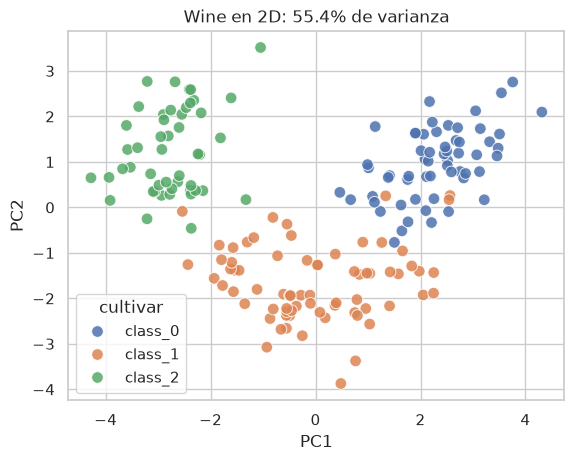

In [18]:
pca_2d = PCA(n_components=2)
X_wine_2d = pca_2d.fit_transform(X_wine_scaled)
wine_2d = pd.DataFrame(X_wine_2d, columns=['PC1', 'PC2'])
wine_2d['cultivar'] = y_wine.map(dict(enumerate(wine.target_names)))

ax = sns.scatterplot(data=wine_2d, x='PC1', y='PC2', hue='cultivar', s=70, alpha=.85)
ax.set_title(f'Wine en 2D: {pca_2d.explained_variance_ratio_.sum():.1%} de varianza')
plt.show()


In [19]:
cargas = pd.DataFrame(
    pca_2d.components_.T,
    index=X_wine.columns,
    columns=['PC1', 'PC2']
)
cargas.assign(magnitud_PC1=cargas['PC1'].abs()).sort_values('magnitud_PC1', ascending=False).head(6)


,PC1,PC2,magnitud_PC1
flavanoids,0.422934,-0.003360,0.422934
total_phenols,0.394661,0.065040,0.394661
od280/od315_of_diluted_wines,0.376167,-0.164496,0.376167
proanthocyanins,0.313429,0.039302,0.313429
nonflavanoid_phenols,-0.298533,0.028779,0.298533
hue,0.296715,-0.279235,0.296715


### Interpretación

- La varianza explicada indica cuánta información lineal conserva cada componente.
- Las cargas muestran qué variables contribuyen a cada eje.
- Separación visual no equivale automáticamente a buen desempeño predictivo.


## Actividad 2 — Decidir el número de componentes

1. Compara los umbrales de 80%, 90% y 95% de varianza.
2. Identifica las variables con mayor carga absoluta en PC1 y PC2.
3. Argumenta el compromiso entre reducción, visualización e información retenida.


# 4. Agrupamiento con K-means

Usaremos **Iris**, con 150 flores y cuatro mediciones. K-means no conoce la especie: solo busca grupos compactos alrededor de centroides.


In [20]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

X_iris_scaled = StandardScaler().fit_transform(X_iris)
print('Dimensiones:', X_iris.shape)
X_iris.head()


Dimensiones: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 4.1 Elegir k con evidencia

La inercia siempre disminuye al aumentar `k`; por ello se complementa con el índice de silueta, que favorece grupos compactos y separados.


In [21]:
resultados_k = []
for k in range(2, 8):
    modelo = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    etiquetas = modelo.fit_predict(X_iris_scaled)
    resultados_k.append({
        'k': k,
        'inercia': modelo.inertia_,
        'silueta': silhouette_score(X_iris_scaled, etiquetas),
    })

resultados_k = pd.DataFrame(resultados_k)
resultados_k


,k,inercia,silueta
0,2,222.361705,0.581750
1,3,139.820496,0.459948
2,4,114.092328,0.384471
3,5,90.807592,0.345511
4,6,80.022188,0.322037
5,7,71.033431,0.327694


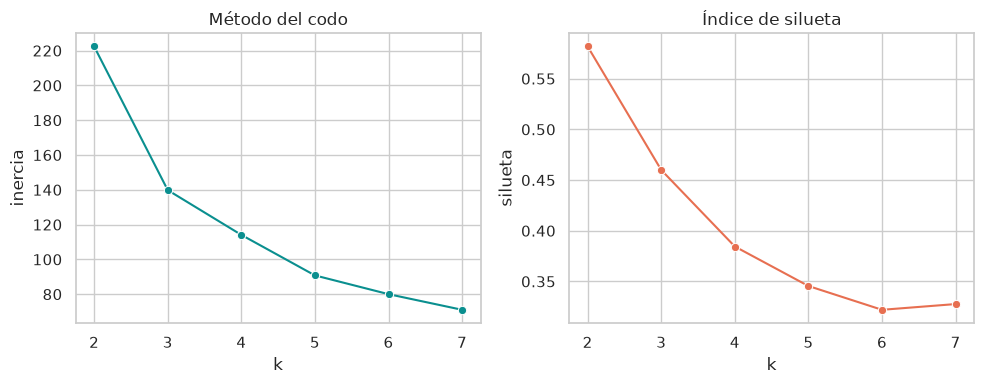

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(data=resultados_k, x='k', y='inercia', marker='o', ax=axes[0], color='#0A8F8F')
sns.lineplot(data=resultados_k, x='k', y='silueta', marker='o', ax=axes[1], color='#E76F51')
axes[0].set_title('Método del codo')
axes[1].set_title('Índice de silueta')
plt.tight_layout()
plt.show()


## 4.2 Resultado para k = 3

Para visualizar los grupos, proyectamos los datos escalados a dos componentes. PCA es solo la vista; K-means se ajusta con las cuatro variables.


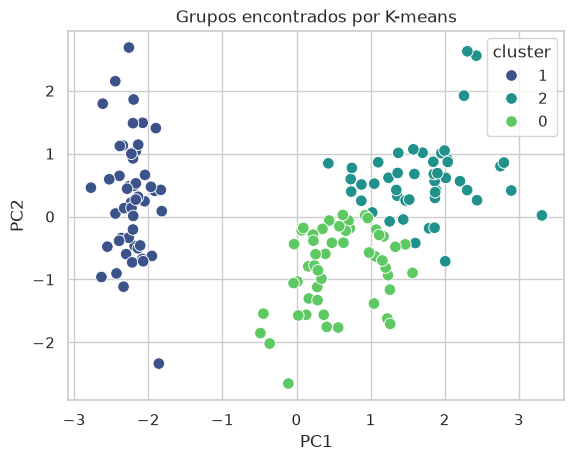

In [23]:
kmeans = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_iris_scaled)

iris_2d = PCA(n_components=2).fit_transform(X_iris_scaled)
grafica_iris = pd.DataFrame(iris_2d, columns=['PC1', 'PC2'])
grafica_iris['cluster'] = clusters.astype(str)

ax = sns.scatterplot(data=grafica_iris, x='PC1', y='PC2', hue='cluster', s=70, palette='viridis')
ax.set_title('Grupos encontrados por K-means')
plt.show()


In [24]:
print(f'Silueta: {silhouette_score(X_iris_scaled, clusters):.3f}')
print(f'ARI frente a las especies (solo para evaluación externa): {adjusted_rand_score(y_iris, clusters):.3f}')


Silueta: 0.460
ARI frente a las especies (solo para evaluación externa): 0.620


### Interpretación responsable

- La silueta evalúa cohesión y separación sin utilizar etiquetas reales.
- El ARI compara los grupos con una referencia externa; no debe utilizarse si el dominio no dispone de etiquetas.
- Un clúster no es automáticamente una categoría útil: debe validarse con conocimiento del dominio.


## Actividad 3 — Comparar soluciones

1. Compara `k = 2`, `k = 3` y `k = 4`.
2. Explica por qué inercia y silueta pueden sugerir decisiones distintas.
3. Describe cada clúster mediante los promedios de sus cuatro atributos.
4. Propón una validación de dominio para decidir si los grupos son útiles.


# 5. Extensión: imágenes de dígitos

El conjunto **Digits** contiene imágenes reales de dígitos manuscritos de 8×8 píxeles. Cada imagen puede representarse como un vector de 64 atributos; PCA permite visualizar su estructura.


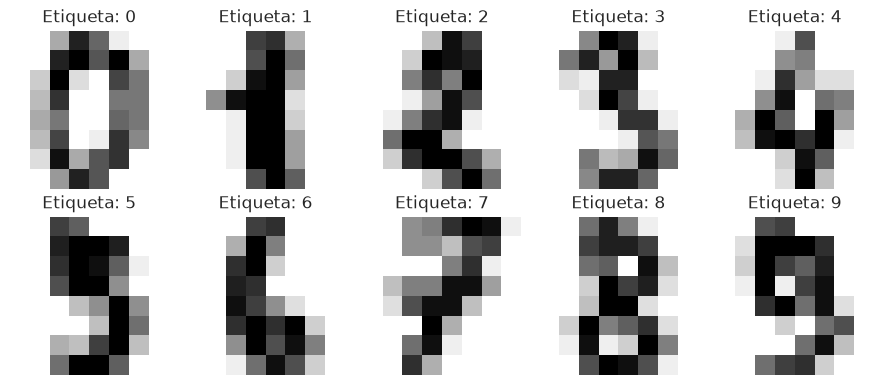

In [25]:
digits = load_digits()
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f'Etiqueta: {digits.target[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


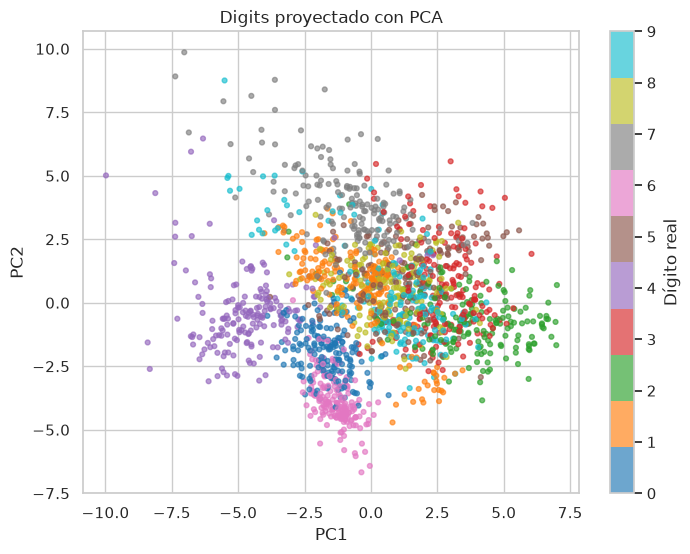

In [26]:
X_digits_scaled = StandardScaler().fit_transform(digits.data)
digits_2d = PCA(n_components=2).fit_transform(X_digits_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(digits_2d[:, 0], digits_2d[:, 1], c=digits.target,
                      cmap='tab10', s=12, alpha=.65)
plt.colorbar(scatter, ticks=range(10), label='Dígito real')
plt.title('Digits proyectado con PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## Fuentes de los conjuntos de datos

- Wolberg, Street y Mangasarian. *Breast Cancer Wisconsin (Diagnostic)*, UCI Machine Learning Repository.
- Forina et al. *Wine recognition data*, UCI Machine Learning Repository.
- Fisher. *Iris*, UCI Machine Learning Repository.
- Alpaydin y Kaynak. *Optical Recognition of Handwritten Digits*, UCI Machine Learning Repository.
- Documentación de `scikit-learn`: conjuntos de datos y métricas utilizadas.
